In [73]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt
import pandas as pd
import eurostat
from data_scraper import *
from plotter import *
import geopandas as gpd
import imageio
import os
from scipy import stats


In [74]:
# Intrested in the year
Y = 2022
filename="connectivity_"+str(Y)+".csv"

# Fetch transportation data
df_connectivity = fetch_eu_air_traffic(year=Y, filename=filename, check=filename)

# Fetch population data
df_pop = fetch_eu_populations(year=Y)
df_pop = df_pop.set_index("Country_Code")

+ Fetching Eurostat Air Traffic Data...
Loaded succesfully!
+ Fetching Eurostat Population Data...
   -> Successfully loaded populations for 50 entities.


In [75]:
# Filter out cities with air traffic and Nan pop values
df_pop = df_pop.dropna()
valid_countries = df_pop.index.tolist()
valid_nodes = [node for node in df_connectivity.index if node in valid_countries]
df_connectivity = df_connectivity.loc[valid_nodes, valid_nodes]
df_pop = df_pop.loc[df_connectivity.index.to_list()]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [76]:
population = df_pop.to_numpy().flatten().copy()

# Generate connectivity matrix
C = df_connectivity.to_numpy().copy()

# Adding sum of rows to diag
C += (np.diag(C.sum(axis=1)) * np.diag(population)) ** 0.65

# Weighting the columns by populations
#C = C * population[:, np.newaxis]

treshold = 0.001


# Normalizing rows, asymmetric matrix; zero diagonal; rows sum to 1
C = C / np.sum(C, axis=1, keepdims=True)

C[C < treshold] = 0

C = C / np.sum(C, axis=1, keepdims=True)

In [77]:
pd.DataFrame(C)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33
0,0.985255,0.000000,0.000000,0.000000,0.000000,0.000000,0.004600,0.000000,0.000000,0.001538,0.002704,0.000000,0.001181,0.000000,0.000000,0.000000,0.000000,0.002155,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001051,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001517
1,0.000000,0.987144,0.000000,0.000000,0.000000,0.000000,0.001121,0.000000,0.000000,0.001039,0.005037,0.000000,0.001589,0.000000,0.000000,0.000000,0.000000,0.002794,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.001269,0.000000,0.987770,0.000000,0.000000,0.000000,0.004685,0.000000,0.000000,0.000000,0.001263,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001763,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001205
3,0.000000,0.000000,0.000000,0.980168,0.000000,0.000000,0.003058,0.000000,0.000000,0.001386,0.004833,0.000000,0.002883,0.000000,0.000000,0.000000,0.000000,0.002205,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001247,0.000000,0.000000,0.002254,0.000000,0.000000,0.000000,0.000000,0.000000,0.001966
4,0.003811,0.000000,0.001504,0.001662,0.949045,0.000000,0.006114,0.001856,0.000000,0.017667,0.000000,0.000000,0.001670,0.000000,0.002211,0.000000,0.000000,0.002266,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001310,0.000000,0.005321,0.000000,0.002029,0.001084,0.002449,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.990979,0.001127,0.000000,0.000000,0.001467,0.001753,0.000000,0.001324,0.000000,0.000000,0.000000,0.000000,0.001983,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001368
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996340,0.000000,0.000000,0.000000,0.002105,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001556
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002243,0.978212,0.000000,0.001615,0.004369,0.000000,0.001860,0.000000,0.000000,0.000000,0.000000,0.001932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002183,0.003006,0.001202,0.000000,0.000000,0.000000,0.001635,0.000000,0.000000,0.001741
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005416,0.000000,0.969873,0.000000,0.001120,0.003774,0.001254,0.000000,0.000000,0.000000,0.000000,0.003881,0.000000,0.000000,0.003453,0.000000,0.000000,0.000000,0.001117,0.001065,0.002233,0.000000,0.000000,0.000000,0.003122,0.000000,0.000000,0.003693
9,0.000000,0.000000,0.000000,0.000000,0.001146,0.000000,0.006100,0.000000,0.000000,0.984565,0.000000,0.000000,0.002367,0.000000,0.000000,0.000000,0.000000,0.002803,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001629,0.000000,0.001392,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [78]:
# Seed 0.1% infection in a moderately populated country; rest fully susceptible

mode = np.median(population)

def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

mode_idx = find_nearest_idx(population, mode)

S0 = population
S0[mode_idx] = 0.999 * mode

I0 = np.zeros_like(population)
I0[mode_idx] = 0.001 * mode

R0 = np.zeros_like(population)
init_state = np.concatenate([S0, I0, R0])

beta = 0.2
mu = 0.03

sim = Simulation(
    populations=population,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=beta,       
    recovery_rate=mu,        
)
sim.solve_system(t_end=360) 
t, S, I, R = sim.get_results()

print("Location :", valid_countries[mode_idx], "; Population :", mode)

Location : AZ ; Population : 6639794.5


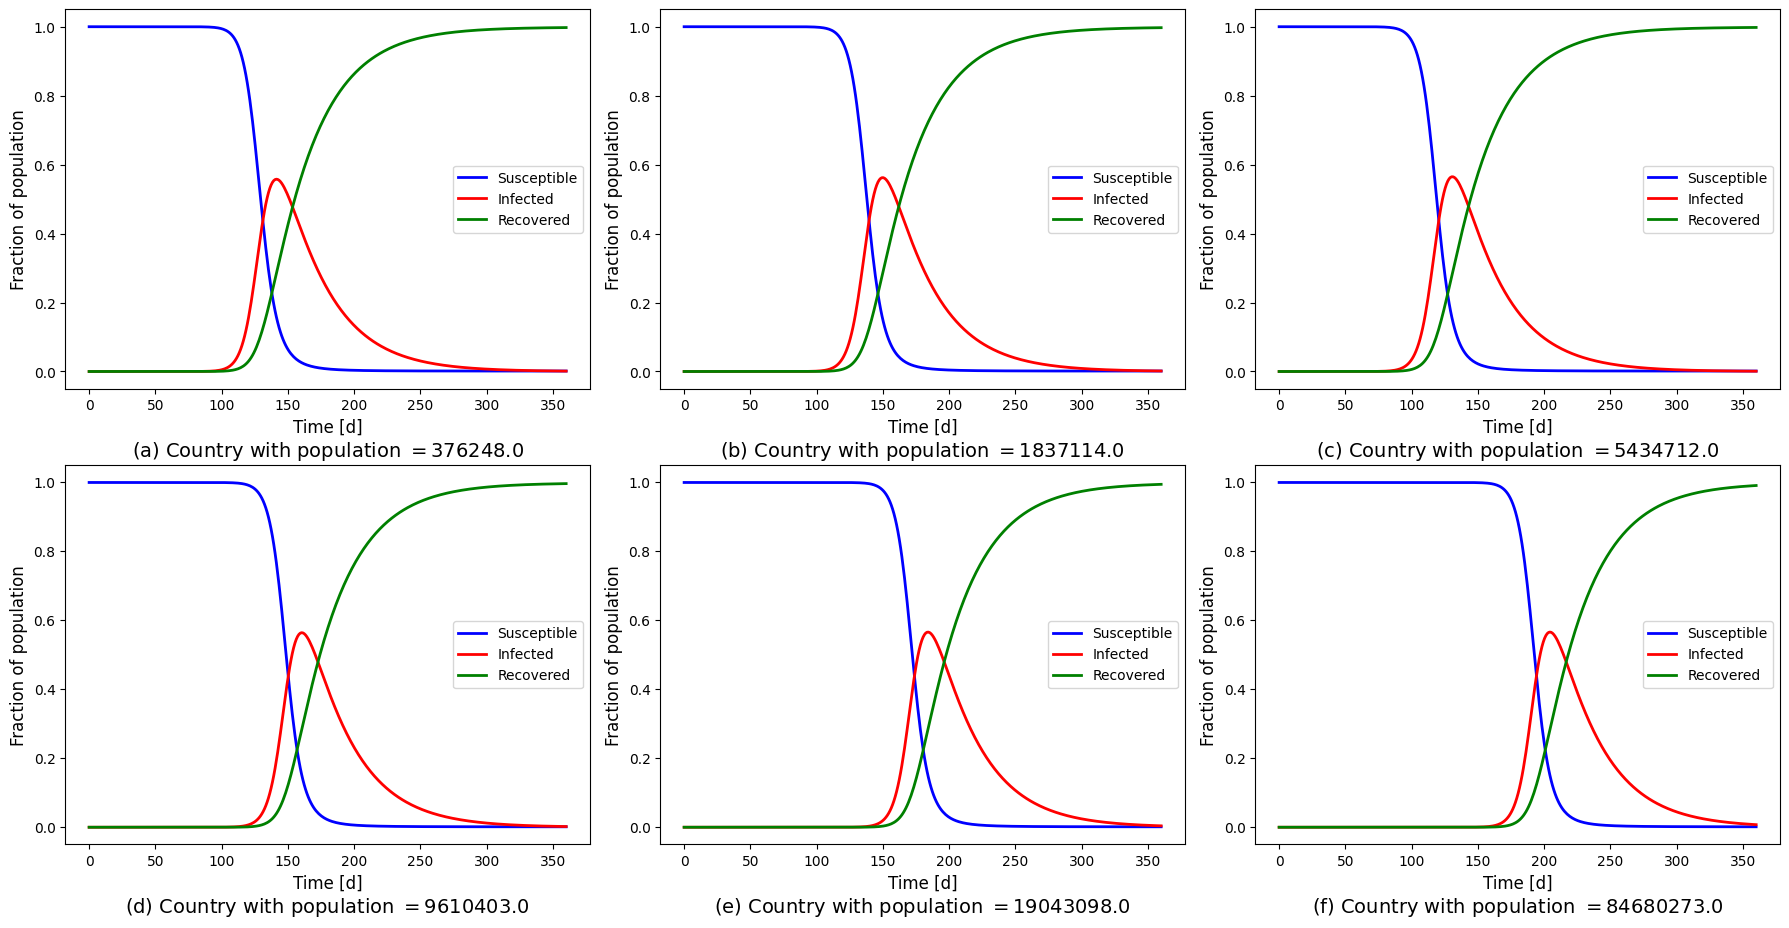

In [79]:
social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=beta, recovery_rate=mu)

Location : HR ; Population : 375871.752


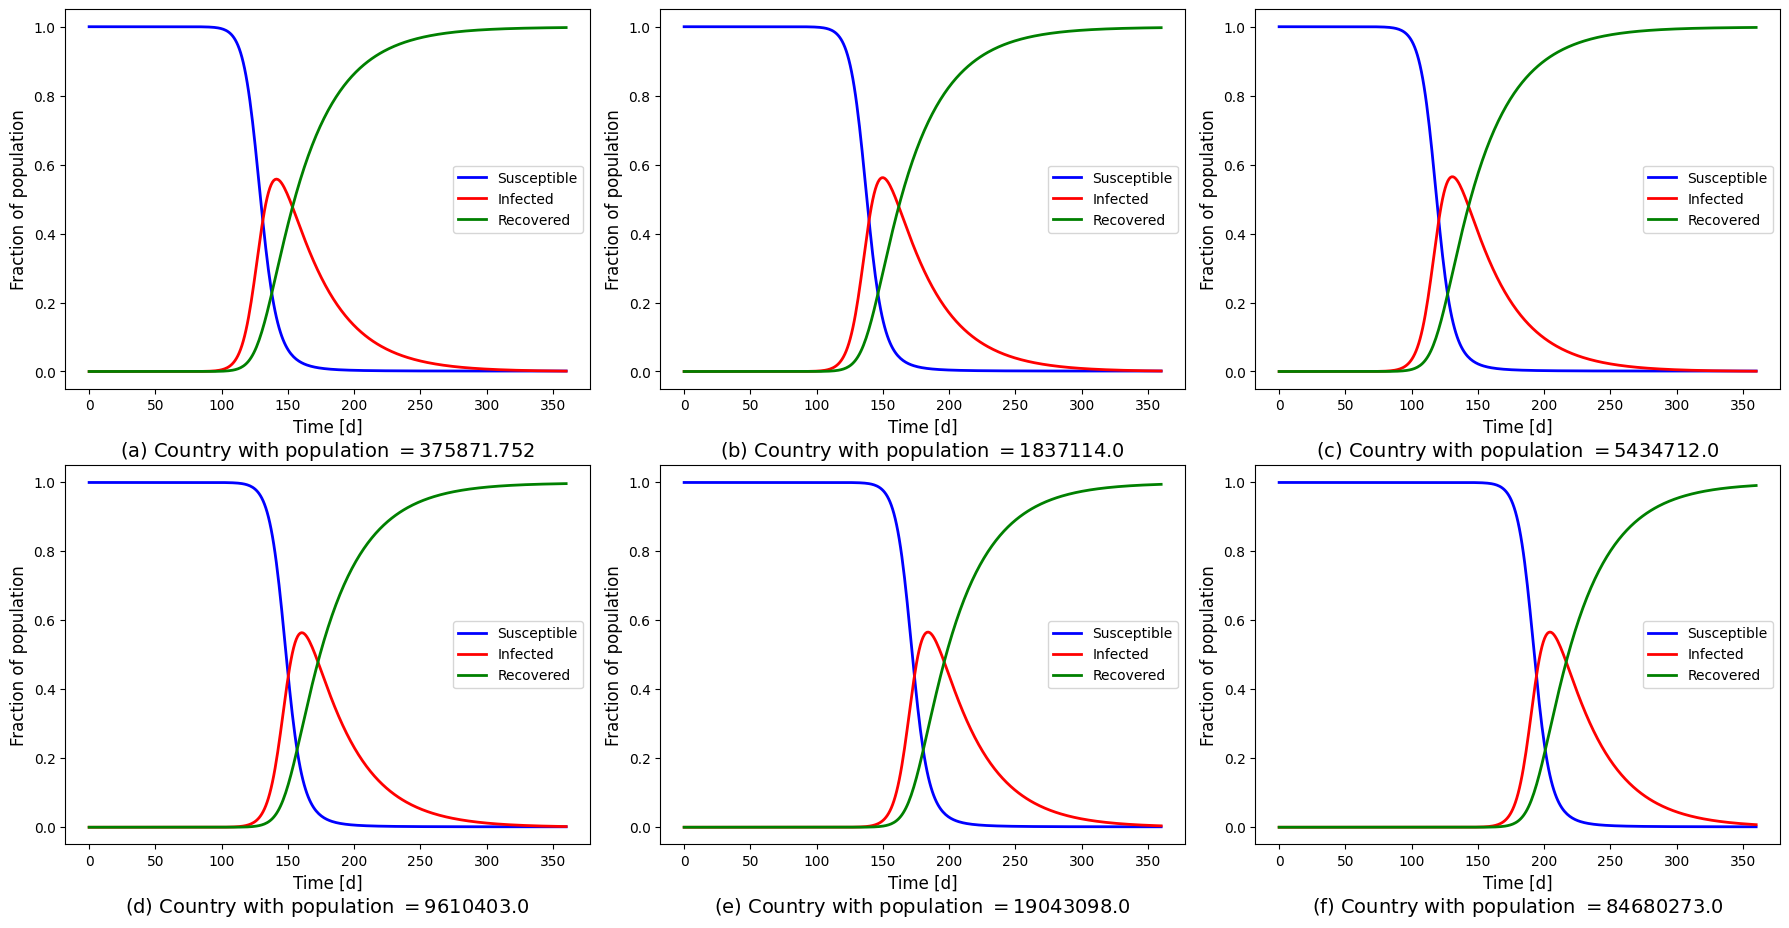

In [80]:
# Seed 0.1% infection in the lowest populated country; rest fully susceptible
S0 = population
S0[np.argmin(population)] = 0.999 * np.min(population)

I0 = np.zeros_like(population)
I0[np.argmin(population)] = 0.001 * np.min(population)

print("Location :", valid_countries[np.argmin(population)], "; Population :", np.min(population))

social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=beta, recovery_rate=mu)

Location : RO ; Population : 84595592.727


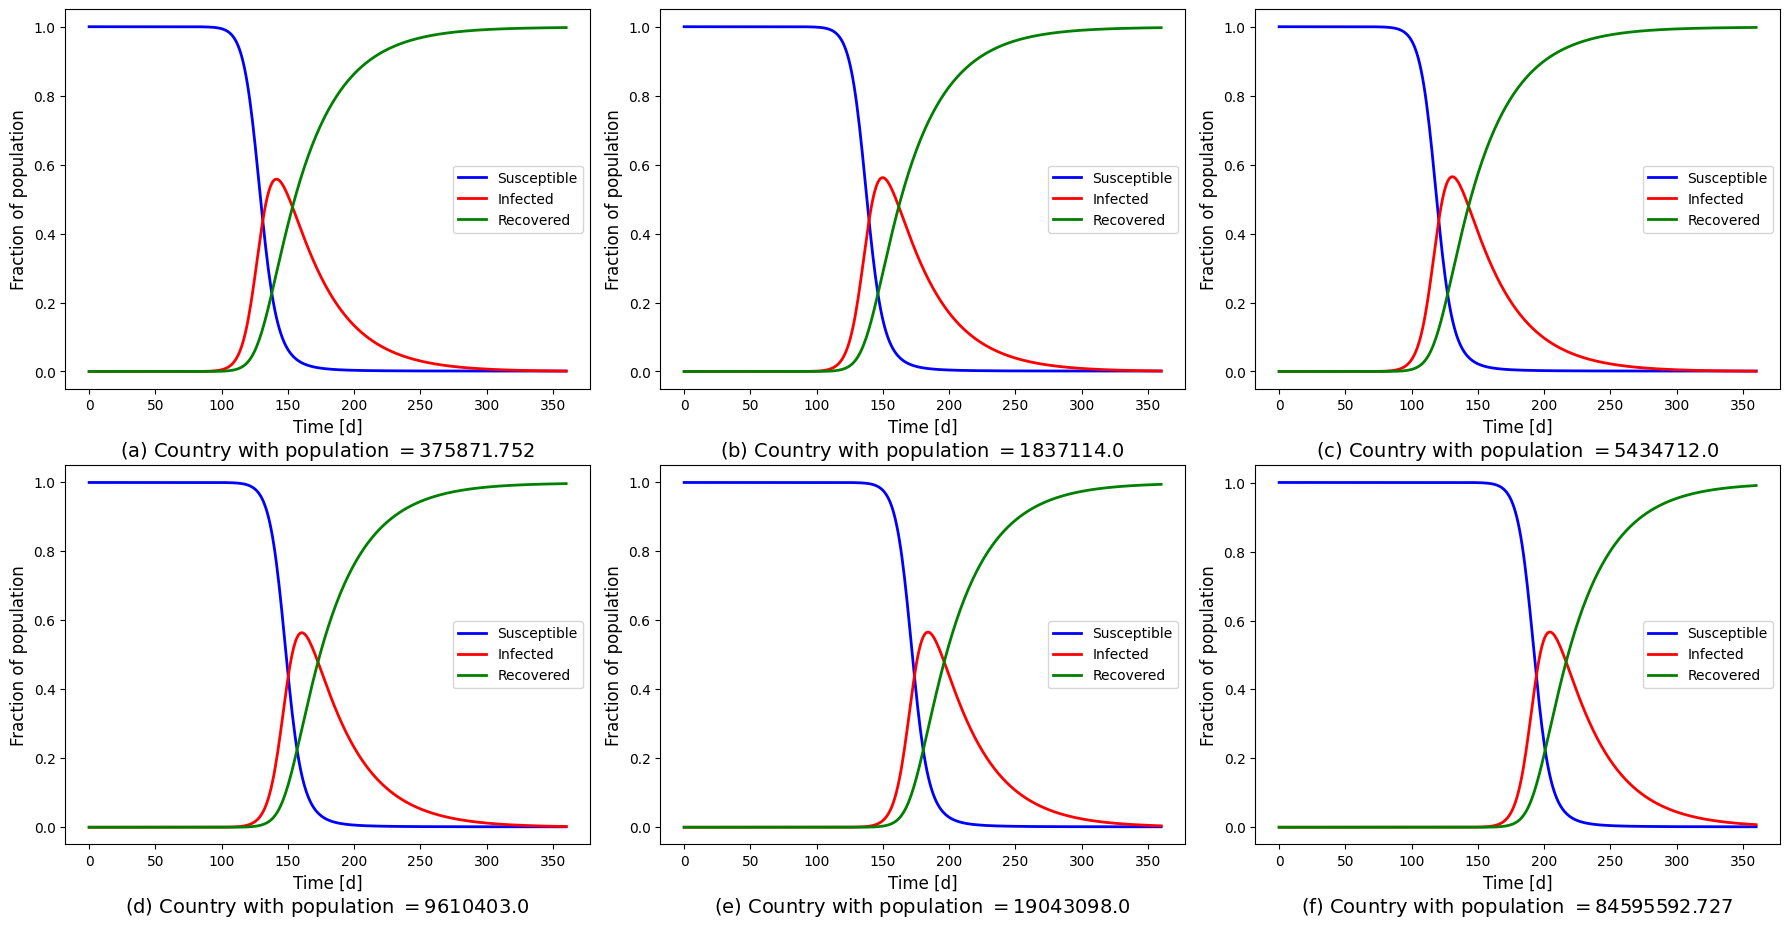

In [81]:
# Seed 0.1% infection in the highest populated country; rest fully susceptible
S0 = population
S0[np.argmax(population)] = 0.999 * np.max(population)

I0 = np.zeros_like(population)
I0[np.argmax(population)] = 0.001 * np.max(population)

print("Location :", valid_countries[np.argmax(population)], "; Population :", np.max(population))

social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=beta, recovery_rate=mu)

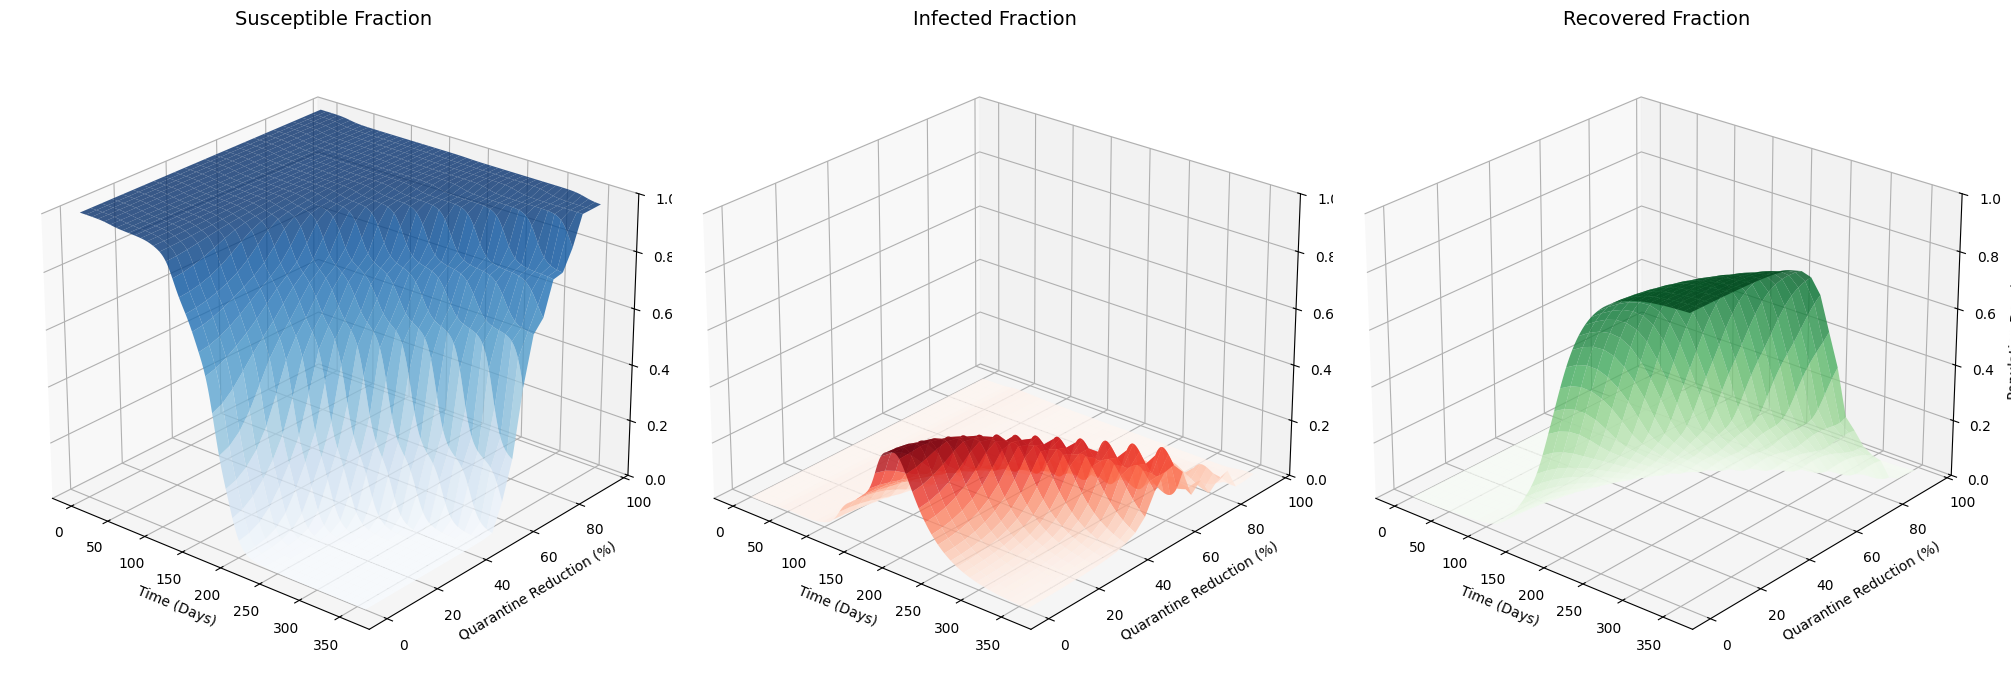

In [82]:
quarantine_plotter_3d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=360)

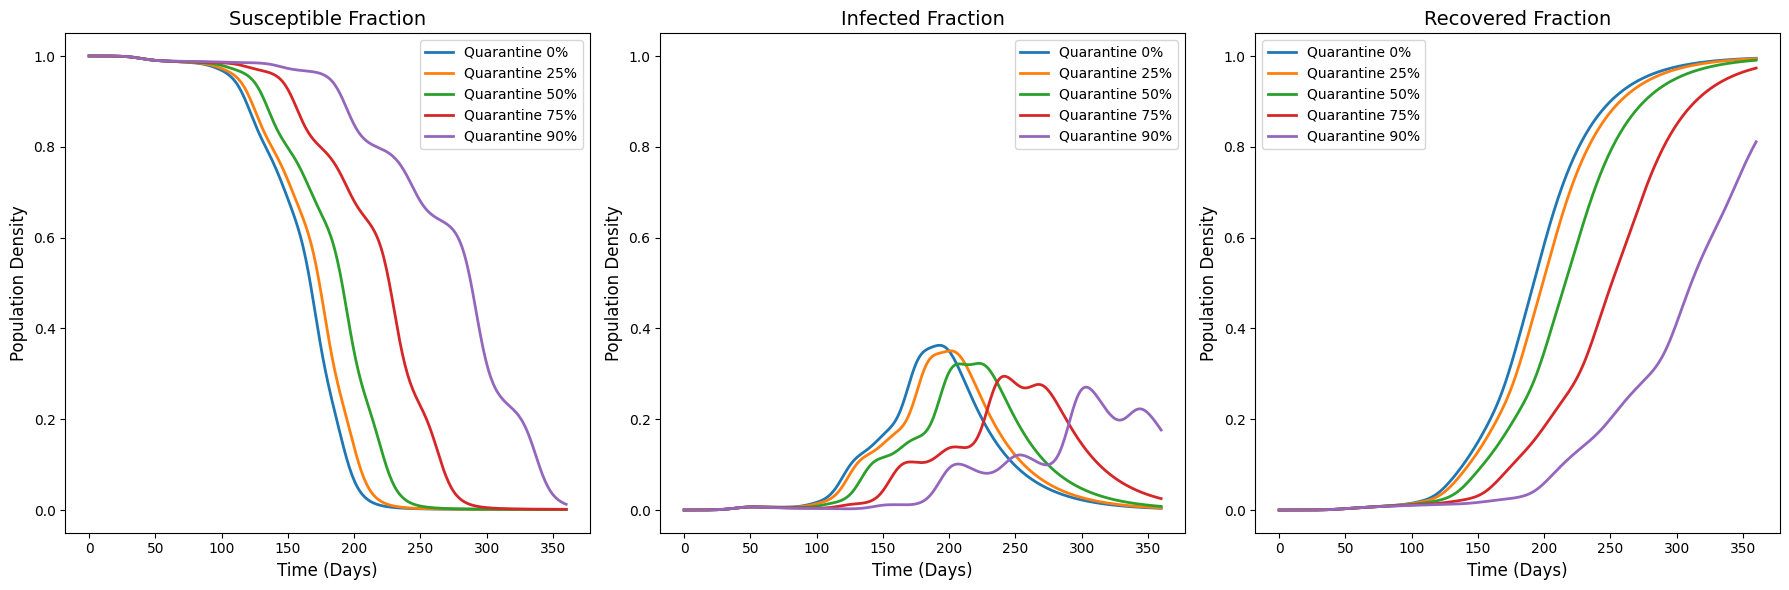

In [83]:
quarantine_plotter_2d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=360)

Running 25 simulations. Please wait...


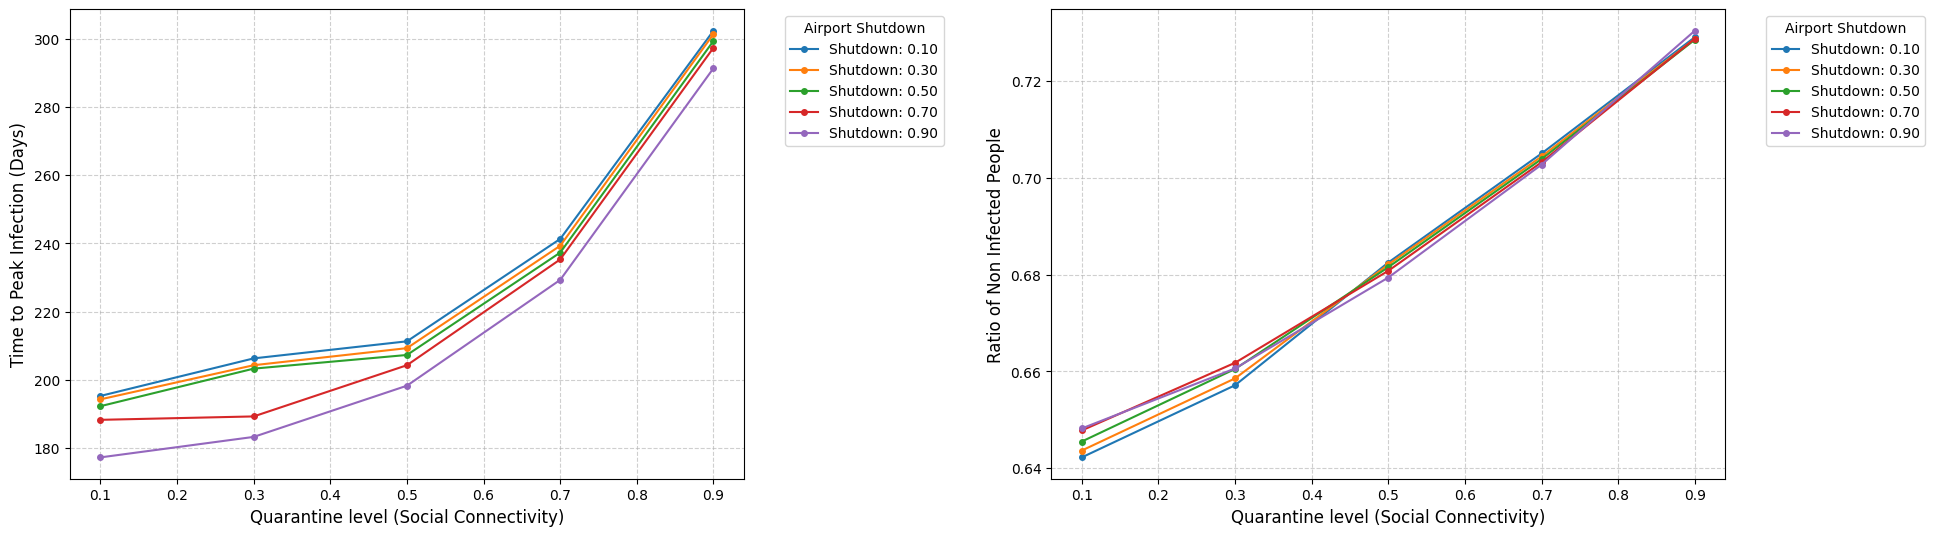

In [84]:
local_vs_global_quarantine_2d(population, init_state, C, beta, mu, 
                               t_end=360, 
                               quarantine_range=np.linspace(0.1, 0.9, 5),
                               top_nodes_under_quarantine=5,
                               social_connectivity_range=np.linspace(0.1, 0.9, 5))

In [85]:
eurostat_codes = df_connectivity.index.to_list()
generate_gif(t, S, I, R, eurostat_codes)

1. Downloading map geometry from Natural Earth...
2. Setting up nodes and translating Eurostat to ISO3...
3. Generating frames...
4. Stitching into GIF...
Success! GIF saved as: sir_eu_model_2x2_new.gif
